# Unified Ablation Study — BERT + XGBoost

This notebook executes the four planned ablation sections using the **existing BERT + XGBoost architecture** and the **fixed best hyperparameters**.

### Ablation sections
1. Single-feature / `goal_usd`
2. Cumulative feature addition
3. Noise robustness on BERT PCA features
4. Preprocessing variations

All sections use the existing train/test split and fixed **PCA = 20** BERT representation. Each section writes its own CSV result file and PNG figure.

In [1]:
%matplotlib inline

import os
import json
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)

from xgboost import XGBRegressor

RANDOM_STATE = 42
USE_GPU = True
N_COMPONENTS = 20

# ---- 0. Paths ----
DATA_DIR = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset"
TRAIN_FILE = f"{DATA_DIR}/ML_train.csv"
TEST_FILE = f"{DATA_DIR}/ML_test.csv"
BERT_FILE = r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\bert_embeddings.csv"

# ---- 1. Fixed best hyperparameters ----
BEST_PARAMS = {
    "colsample_bytree": 0.9512165066659852,
    "learning_rate": 0.07643904937766527,
    "max_depth": 6,
    "min_child_weight": 7,
    "n_estimators": 459,
    "reg_alpha": 0.0014729254229045347,
    "reg_lambda": 0.845771345696438,
    "subsample": 0.8060762192885254,
}

TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"
DROP_ALWAYS = ["id", "target_usd", "log_target"]  # goal_usd handled per-ablation


In [2]:
# ---- 2. Load data + fixed PCA (N=20) ----
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
bert_raw = pd.read_csv(BERT_FILE)

train_ids = set(train_df["id"])
feature_cols = [c for c in bert_raw.columns if c != "id"]
train_mask = bert_raw["id"].isin(train_ids)

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(bert_raw.loc[train_mask, feature_cols])
reduced_all = pca.transform(bert_raw[feature_cols])
reduced_cols = [f"bert_pca_{i}" for i in range(N_COMPONENTS)]
reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
reduced_df.insert(0, "id", bert_raw["id"].values)

merged_train = train_df.merge(reduced_df, on="id", how="left")
merged_test = test_df.merge(reduced_df, on="id", how="left")

y_train = merged_train[TARGET_LOG].copy()
y_test = merged_test[TARGET_LOG].copy()
actual_usd = merged_test[TARGET_RAW].to_numpy()

print(f"Train rows: {len(merged_train)} | Test rows: {len(merged_test)} | BERT PCA dims: {N_COMPONENTS}")
print(f"Train columns: {len(merged_train.columns)} | Test columns: {len(merged_test.columns)}")


Train rows: 16000 | Test rows: 4000 | BERT PCA dims: 20
Train columns: 101 | Test columns: 101


In [3]:
# ---- 3. Shared evaluation helper ----
def evaluate_model(y_true_log, pred_log, actual_usd):
    pred_usd = np.expm1(pred_log)
    pred_usd = np.clip(pred_usd, a_min=0, a_max=None)

    mae_log = mean_absolute_error(y_true_log, pred_log)
    mse_log = mean_squared_error(y_true_log, pred_log)
    rmse_log = np.sqrt(mse_log)
    r2_log = r2_score(y_true_log, pred_log)

    mae_usd = mean_absolute_error(actual_usd, pred_usd)
    mse_usd = mean_squared_error(actual_usd, pred_usd)
    rmse_usd = np.sqrt(mse_usd)
    r2_usd = r2_score(actual_usd, pred_usd)

    rmsle = np.sqrt(mean_squared_log_error(actual_usd, pred_usd))

    return {
        "MAE_log": mae_log, "MSE_log": mse_log, "RMSE_log": rmse_log, "R2_log": r2_log,
        "MAE_USD": mae_usd, "MSE_USD": mse_usd, "RMSE_USD": rmse_usd, "R2_USD": r2_usd,
        "RMSLE": rmsle
    }

def fit_and_eval(X_train, X_test, y_train=y_train, y_test=y_test, actual_usd=actual_usd):
    model = XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", device="cuda" if USE_GPU else "cpu",
        random_state=RANDOM_STATE,
        **BEST_PARAMS,
    )
    model.fit(X_train, y_train)
    pred_log = model.predict(X_test)
    return evaluate_model(y_test, pred_log, actual_usd), model


## Section 1 — Single-feature ablation: `goal_usd`

In [4]:
# =========================================================
# SECTION 1: Single-feature ablation — goal_usd
# =========================================================
print("\n" + "#"*70)
print("# SECTION 1: goal_usd ablation")
print("#"*70)

X_train_without_goal = merged_train.drop(columns=DROP_ALWAYS + ["goal_usd"], errors="ignore")
X_test_without_goal = merged_test.drop(columns=DROP_ALWAYS + ["goal_usd"], errors="ignore")

X_train_with_goal = merged_train.drop(columns=DROP_ALWAYS, errors="ignore")
X_test_with_goal = merged_test.drop(columns=DROP_ALWAYS, errors="ignore")

assert list(X_train_without_goal.columns) == list(X_test_without_goal.columns)
assert list(X_train_with_goal.columns) == list(X_test_with_goal.columns)

metrics_without_goal, _ = fit_and_eval(X_train_without_goal, X_test_without_goal)
metrics_without_goal["Variant"] = "Without goal_usd"

metrics_with_goal, _ = fit_and_eval(X_train_with_goal, X_test_with_goal)
metrics_with_goal["Variant"] = "With goal_usd"

goal_results_df = pd.DataFrame([metrics_without_goal, metrics_with_goal])
goal_results_df = goal_results_df[[
    "Variant", "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD", "RMSLE"
]]
print(goal_results_df)
goal_results_df.to_csv("ablation1_goal_usd_results.csv", index=False)
print("Saved: ablation1_goal_usd_results.csv")



######################################################################
# SECTION 1: goal_usd ablation
######################################################################
            Variant   MAE_log   MSE_log  RMSE_log    R2_log       MAE_USD  \
0  Without goal_usd  1.115845  2.275488  1.508472  0.757791  14587.044370   
1     With goal_usd  1.110859  2.236387  1.495455  0.761953  14825.776505   

        MSE_USD       RMSE_USD    R2_USD     RMSLE  
0  9.713670e+09   98557.950385  0.176912  1.506474  
1  1.032156e+10  101595.102784  0.125402  1.493390  
Saved: ablation1_goal_usd_results.csv


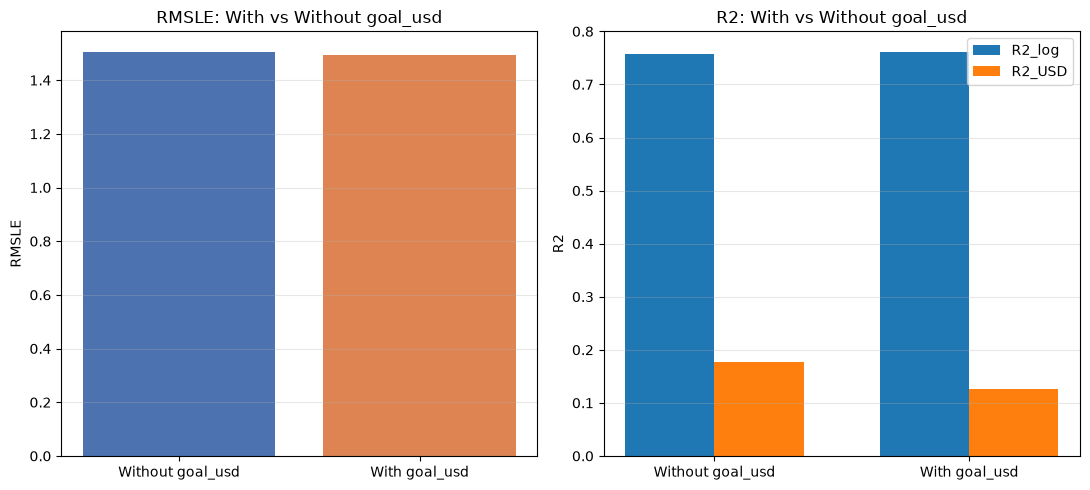

Saved: ablation1_goal_usd_plot.png


In [5]:
# Plot 1
fig1, axes1 = plt.subplots(1, 2, figsize=(11, 5))
axes1[0].bar(goal_results_df["Variant"], goal_results_df["RMSLE"], color=["#4C72B0", "#DD8452"])
axes1[0].set_ylabel("RMSLE")
axes1[0].set_title("RMSLE: With vs Without goal_usd")
axes1[0].grid(True, alpha=0.3, axis="y")

x1 = np.arange(len(goal_results_df))
width = 0.35
axes1[1].bar(x1 - width/2, goal_results_df["R2_log"], width, label="R2_log")
axes1[1].bar(x1 + width/2, goal_results_df["R2_USD"], width, label="R2_USD")
axes1[1].set_xticks(x1)
axes1[1].set_xticklabels(goal_results_df["Variant"])
axes1[1].set_ylabel("R2")
axes1[1].set_title("R2: With vs Without goal_usd")
axes1[1].legend()
axes1[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("ablation1_goal_usd_plot.png", dpi=150)
plt.show()
print("Saved: ablation1_goal_usd_plot.png")


## Section 2 — Cumulative feature addition

In [6]:
# =========================================================
# SECTION 2: Cumulative feature-addition
# =========================================================
print("\n" + "#"*70)
print("# SECTION 2: Cumulative feature-addition")
print("#"*70)

all_cols = [c for c in merged_train.columns if c not in DROP_ALWAYS + ["goal_usd"]]
category_cols = [c for c in all_cols if "category" in c.lower()]
location_cols = [c for c in all_cols if "location" in c.lower() or c in ["country", "currency"]]
timing_cols = [c for c in all_cols if "launch" in c.lower() or "duration" in c.lower() or "prelaunch" in c.lower()]
already_used = set(reduced_cols + category_cols + location_cols + timing_cols)
other_cols = [c for c in all_cols if c not in already_used]

cumulative_stages = [
    ("BERT-only", reduced_cols),
    ("+Category", reduced_cols + category_cols),
    ("+Location", reduced_cols + category_cols + location_cols),
    ("+Timing", reduced_cols + category_cols + location_cols + timing_cols),
    ("+Other", reduced_cols + category_cols + location_cols + timing_cols + other_cols),
    ("+goal_usd (full)", reduced_cols + category_cols + location_cols + timing_cols + other_cols + ["goal_usd"]),
]

cumulative_results = []
for stage_name, cols in cumulative_stages:
    cols = list(dict.fromkeys(cols))
    X_tr = merged_train[cols]
    X_te = merged_test[cols]
    metrics, _ = fit_and_eval(X_tr, X_te)
    metrics["Stage"] = stage_name
    metrics["N_Features"] = len(cols)
    cumulative_results.append(metrics)
    print(f"{stage_name}: N={len(cols)} | RMSLE={metrics['RMSLE']:.4f} | "
          f"R2_log={metrics['R2_log']:.4f} | R2_USD={metrics['R2_USD']:.4f}")

cumulative_df = pd.DataFrame(cumulative_results)
cumulative_df = cumulative_df[[
    "Stage", "N_Features", "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD", "RMSLE"
]]
print(cumulative_df)
cumulative_df.to_csv("ablation2_cumulative_feature_results.csv", index=False)
print("Saved: ablation2_cumulative_feature_results.csv")



######################################################################
# SECTION 2: Cumulative feature-addition
######################################################################
BERT-only: N=20 | RMSLE=1.7990 | R2_log=0.6544 | R2_USD=0.1262
+Category: N=35 | RMSLE=1.7408 | R2_log=0.6768 | R2_USD=0.1239
+Location: N=45 | RMSLE=1.7268 | R2_log=0.6819 | R2_USD=0.1450
+Timing: N=53 | RMSLE=1.6254 | R2_log=0.7183 | R2_USD=0.1296
+Other: N=97 | RMSLE=1.5039 | R2_log=0.7587 | R2_USD=0.1534
+goal_usd (full): N=98 | RMSLE=1.5147 | R2_log=0.7549 | R2_USD=0.1643
              Stage  N_Features   MAE_log   MSE_log  RMSE_log    R2_log  \
0         BERT-only          20  1.362447  3.246647  1.801846  0.654419   
1         +Category          35  1.313373  3.036844  1.742654  0.676751   
2         +Location          45  1.303779  2.988015  1.728587  0.681948   
3           +Timing          53  1.235306  2.646034  1.626663  0.718350   
4            +Other          97  1.112299  2.266946  1.505638

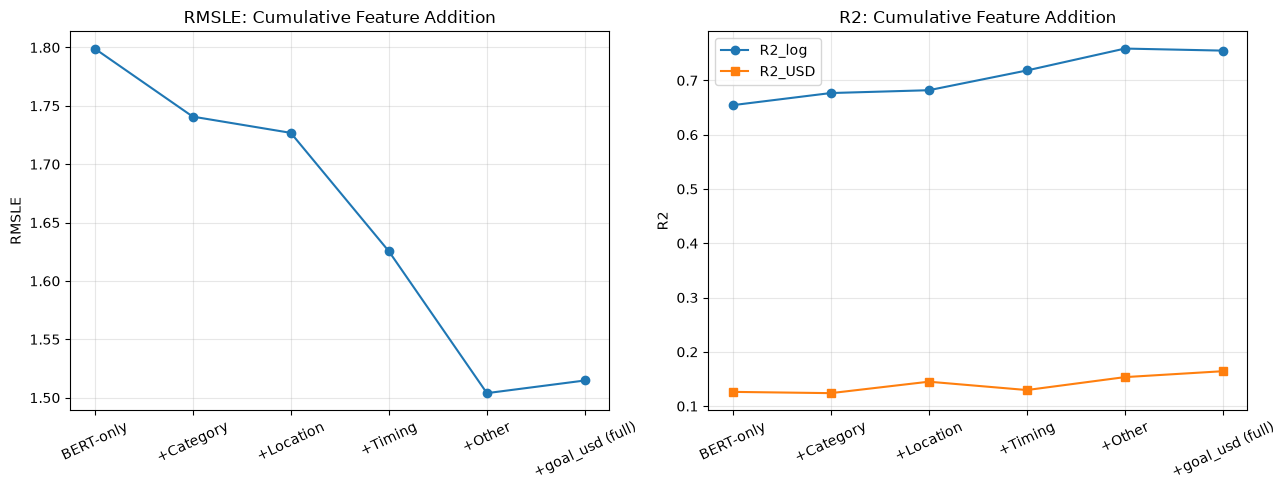

Saved: ablation2_cumulative_feature_plot.png


In [7]:
# Plot 2
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
axes2[0].plot(cumulative_df["Stage"], cumulative_df["RMSLE"], marker="o")
axes2[0].set_ylabel("RMSLE")
axes2[0].set_title("RMSLE: Cumulative Feature Addition")
axes2[0].tick_params(axis="x", rotation=25)
axes2[0].grid(True, alpha=0.3)

axes2[1].plot(cumulative_df["Stage"], cumulative_df["R2_log"], marker="o", label="R2_log")
axes2[1].plot(cumulative_df["Stage"], cumulative_df["R2_USD"], marker="s", label="R2_USD")
axes2[1].set_ylabel("R2")
axes2[1].set_title("R2: Cumulative Feature Addition")
axes2[1].tick_params(axis="x", rotation=25)
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ablation2_cumulative_feature_plot.png", dpi=150)
plt.show()
print("Saved: ablation2_cumulative_feature_plot.png")


## Section 3 — Noise robustness

In [8]:
# =========================================================
# SECTION 3: Noise robustness (BERT PCA columns perturbed at test time)
# =========================================================
print("\n" + "#"*70)
print("# SECTION 3: Noise robustness")
print("#"*70)

X_train_full = merged_train.drop(columns=DROP_ALWAYS, errors="ignore")
X_test_full = merged_test.drop(columns=DROP_ALWAYS, errors="ignore")
assert list(X_train_full.columns) == list(X_test_full.columns)

# Fit once on clean data
_, noise_model = fit_and_eval(X_train_full, X_test_full)

NOISE_LEVELS = [0.0, 0.10, 0.25, 0.50, 1.00]
rng = np.random.RandomState(RANDOM_STATE)

noise_results = []
col_stds = X_test_full[reduced_cols].std()

for level in NOISE_LEVELS:
    X_test_noisy = X_test_full.copy()
    if level > 0:
        noise = rng.normal(loc=0.0, scale=1.0, size=X_test_noisy[reduced_cols].shape)
        noise = noise * (col_stds.values * level)
        X_test_noisy[reduced_cols] = X_test_noisy[reduced_cols].values + noise

    pred_log = noise_model.predict(X_test_noisy)
    metrics = evaluate_model(y_test, pred_log, actual_usd)
    metrics["Noise_Level_Pct"] = int(level * 100)
    noise_results.append(metrics)
    print(f"Noise={int(level*100)}%: RMSLE={metrics['RMSLE']:.4f} | "
          f"R2_log={metrics['R2_log']:.4f} | R2_USD={metrics['R2_USD']:.4f}")

noise_df = pd.DataFrame(noise_results)
noise_df = noise_df[[
    "Noise_Level_Pct", "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD", "RMSLE"
]]
print(noise_df)
noise_df.to_csv("ablation3_noise_robustness_results.csv", index=False)
print("Saved: ablation3_noise_robustness_results.csv")



######################################################################
# SECTION 3: Noise robustness
######################################################################
Noise=0%: RMSLE=1.4934 | R2_log=0.7620 | R2_USD=0.1254
Noise=10%: RMSLE=1.5321 | R2_log=0.7496 | R2_USD=0.1613
Noise=25%: RMSLE=1.7119 | R2_log=0.6859 | R2_USD=0.0586
Noise=50%: RMSLE=2.1326 | R2_log=0.5092 | R2_USD=0.0075
Noise=100%: RMSLE=3.1361 | R2_log=-0.1138 | R2_USD=-0.7411
   Noise_Level_Pct   MAE_log    MSE_log  RMSE_log    R2_log       MAE_USD  \
0                0  1.110859   2.236387  1.495455  0.761953  14825.776505   
1               10  1.139626   2.352848  1.533900  0.749557  14840.802397   
2               25  1.277181   2.950669  1.717751  0.685923  15867.845052   
3               50  1.623156   4.610732  2.147261  0.509222  18366.589279   
4              100  2.452526  10.463416  3.234720 -0.113752  25990.732406   

        MSE_USD       RMSE_USD    R2_USD     RMSLE  
0  1.032156e+10  101595.10278

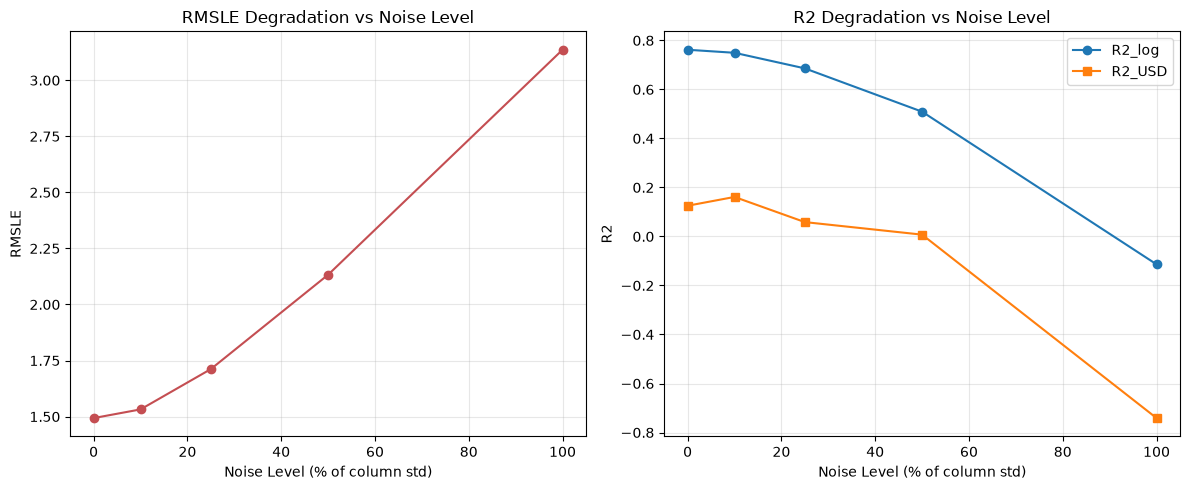

Saved: ablation3_noise_robustness_plot.png


In [9]:
# Plot 3
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
axes3[0].plot(noise_df["Noise_Level_Pct"], noise_df["RMSLE"], marker="o", color="#C44E52")
axes3[0].set_xlabel("Noise Level (% of column std)")
axes3[0].set_ylabel("RMSLE")
axes3[0].set_title("RMSLE Degradation vs Noise Level")
axes3[0].grid(True, alpha=0.3)

axes3[1].plot(noise_df["Noise_Level_Pct"], noise_df["R2_log"], marker="o", label="R2_log")
axes3[1].plot(noise_df["Noise_Level_Pct"], noise_df["R2_USD"], marker="s", label="R2_USD")
axes3[1].set_xlabel("Noise Level (% of column std)")
axes3[1].set_ylabel("R2")
axes3[1].set_title("R2 Degradation vs Noise Level")
axes3[1].legend()
axes3[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ablation3_noise_robustness_plot.png", dpi=150)
plt.show()
print("Saved: ablation3_noise_robustness_plot.png")


## Section 4 — Preprocessing ablation

In [10]:
# =========================================================
# SECTION 4: Preprocessing ablation
# =========================================================
print("\n" + "#"*70)
print("# SECTION 4: Preprocessing ablation")
print("#"*70)

numeric_tabular_cols = [c for c in X_train_full.columns
                         if c not in reduced_cols and X_train_full[c].dtype in [np.float64, np.int64]]

preprocessing_results = []

# --- Variant A: Baseline (no scaling, raw values) ---
metrics_baseline, _ = fit_and_eval(X_train_full, X_test_full)
metrics_baseline["Variant"] = "Baseline (raw)"
preprocessing_results.append(metrics_baseline)

# --- Variant B: StandardScaler on numeric tabular features ---
scaler = StandardScaler()
X_train_scaled = X_train_full.copy()
X_test_scaled = X_test_full.copy()
X_train_scaled[numeric_tabular_cols] = scaler.fit_transform(X_train_full[numeric_tabular_cols])
X_test_scaled[numeric_tabular_cols] = scaler.transform(X_test_full[numeric_tabular_cols])

metrics_scaled, _ = fit_and_eval(X_train_scaled, X_test_scaled)
metrics_scaled["Variant"] = "+StandardScaler"
preprocessing_results.append(metrics_scaled)

# --- Variant C: log1p transform on duration_days / prelaunch_days ---
X_train_log = X_train_full.copy()
X_test_log = X_test_full.copy()
for col in ["duration_days", "prelaunch_days"]:
    if col in X_train_log.columns:
        X_train_log[col] = np.log1p(X_train_log[col].clip(lower=0))
        X_test_log[col] = np.log1p(X_test_log[col].clip(lower=0))

metrics_log, _ = fit_and_eval(X_train_log, X_test_log)
metrics_log["Variant"] = "+log1p(duration/prelaunch)"
preprocessing_results.append(metrics_log)

preprocessing_df = pd.DataFrame(preprocessing_results)
preprocessing_df = preprocessing_df[[
    "Variant", "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD", "RMSLE"
]]
print(preprocessing_df)
preprocessing_df.to_csv("ablation4_preprocessing_results.csv", index=False)
print("Saved: ablation4_preprocessing_results.csv")



######################################################################
# SECTION 4: Preprocessing ablation
######################################################################
                      Variant   MAE_log   MSE_log  RMSE_log    R2_log  \
0              Baseline (raw)  1.110859  2.236387  1.495455  0.761953   
1             +StandardScaler  1.110859  2.236387  1.495455  0.761953   
2  +log1p(duration/prelaunch)  1.110859  2.236387  1.495455  0.761953   

        MAE_USD       MSE_USD       RMSE_USD    R2_USD    RMSLE  
0  14825.776505  1.032156e+10  101595.102784  0.125402  1.49339  
1  14825.776505  1.032156e+10  101595.102784  0.125402  1.49339  
2  14825.776505  1.032156e+10  101595.102784  0.125402  1.49339  
Saved: ablation4_preprocessing_results.csv


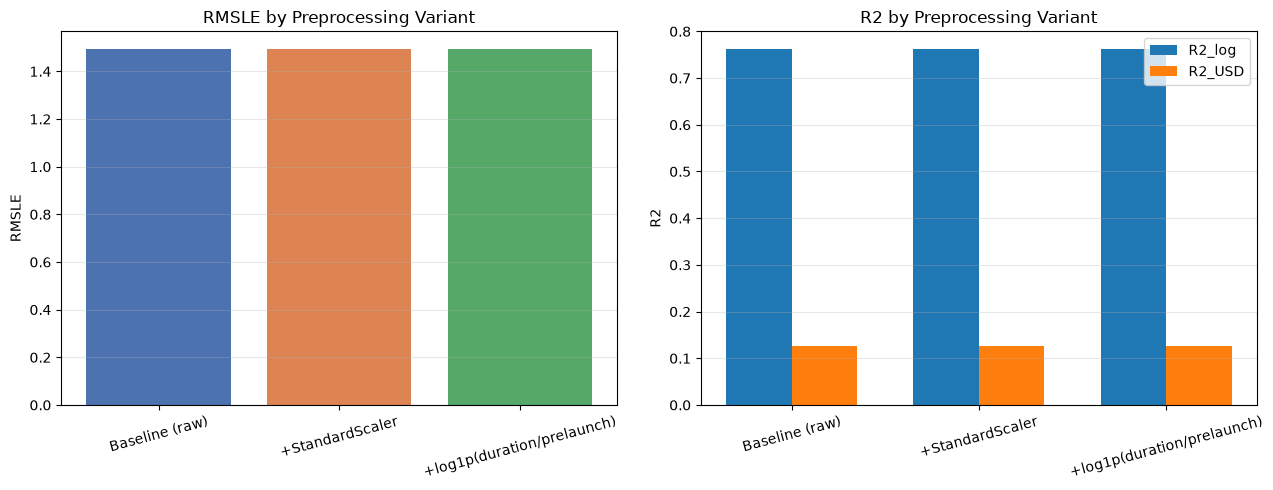

Saved: ablation4_preprocessing_plot.png


In [11]:
# Plot 4
fig4, axes4 = plt.subplots(1, 2, figsize=(13, 5))
axes4[0].bar(preprocessing_df["Variant"], preprocessing_df["RMSLE"], color=["#4C72B0", "#DD8452", "#55A868"])
axes4[0].set_ylabel("RMSLE")
axes4[0].set_title("RMSLE by Preprocessing Variant")
axes4[0].tick_params(axis="x", rotation=15)
axes4[0].grid(True, alpha=0.3, axis="y")

x4 = np.arange(len(preprocessing_df))
width = 0.35
axes4[1].bar(x4 - width/2, preprocessing_df["R2_log"], width, label="R2_log")
axes4[1].bar(x4 + width/2, preprocessing_df["R2_USD"], width, label="R2_USD")
axes4[1].set_xticks(x4)
axes4[1].set_xticklabels(preprocessing_df["Variant"], rotation=15)
axes4[1].set_ylabel("R2")
axes4[1].set_title("R2 by Preprocessing Variant")
axes4[1].legend()
axes4[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("ablation4_preprocessing_plot.png", dpi=150)
plt.show()
print("Saved: ablation4_preprocessing_plot.png")


In [12]:
print("\n" + "="*70)
print("ALL 4 ABLATIONS COMPLETE")
print("="*70)
print("CSV files:")
print("  ablation1_goal_usd_results.csv")
print("  ablation2_cumulative_feature_results.csv")
print("  ablation3_noise_robustness_results.csv")
print("  ablation4_preprocessing_results.csv")
print("\nPNG files:")
print("  ablation1_goal_usd_plot.png")
print("  ablation2_cumulative_feature_plot.png")
print("  ablation3_noise_robustness_plot.png")
print("  ablation4_preprocessing_plot.png")



ALL 4 ABLATIONS COMPLETE
CSV files:
  ablation1_goal_usd_results.csv
  ablation2_cumulative_feature_results.csv
  ablation3_noise_robustness_results.csv
  ablation4_preprocessing_results.csv

PNG files:
  ablation1_goal_usd_plot.png
  ablation2_cumulative_feature_plot.png
  ablation3_noise_robustness_plot.png
  ablation4_preprocessing_plot.png
